# Bank Term Deposit – Marketing Analytics & Prediction

**Tasks**

1. Prepare a complete data analysis report on the given bank marketing data.  
2. Build a predictive model to identify which customer is likely to subscribe to a term deposit (y = "yes").  
3. Give suggestions to the bank marketing team to improve conversions.  
4. Compare multiple ML models and recommend one for production.  
5. Document challenges faced and techniques used to overcome them.


In [2]:
# Basic packages
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [4]:
# Load data
df = pd.read_csv("bank-full.csv", sep=';')  # UCI version uses ';' as separator
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Basic Data Checks
- Shape of data
- Data types
- Missing values / unknown labels
- Basic statistics


In [7]:
df.shape


(45211, 17)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [11]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [13]:
# Check missing values
df.isna().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [15]:
# Many "unknown" values are encoded as string, not NaN.
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].value_counts(normalize=True).head())
    print("-" * 40)


job job
blue-collar    0.215257
management     0.209197
technician     0.168034
admin.         0.114375
services       0.091880
Name: proportion, dtype: float64
----------------------------------------
marital marital
married     0.601933
single      0.282896
divorced    0.115171
Name: proportion, dtype: float64
----------------------------------------
education education
secondary    0.513194
tertiary     0.294198
primary      0.151534
unknown      0.041074
Name: proportion, dtype: float64
----------------------------------------
default default
no     0.981973
yes    0.018027
Name: proportion, dtype: float64
----------------------------------------
housing housing
yes    0.555838
no     0.444162
Name: proportion, dtype: float64
----------------------------------------
loan loan
no     0.839774
yes    0.160226
Name: proportion, dtype: float64
----------------------------------------
contact contact
cellular     0.647741
unknown      0.287983
telephone    0.064276
Name: proportion, dty

## Domain & Target Variable

- Each row = one marketing contact to an existing bank customer.
- **Target variable**: `y` – whether customer subscribed to a term deposit ("yes"/"no").
- Business goal: call customers with higher probability of "yes" to increase conversion and reduce cost.


In [18]:
df['y'].value_counts(), df['y'].value_counts(normalize=True)


(y
 no     39922
 yes     5289
 Name: count, dtype: int64,
 y
 no     0.883015
 yes    0.116985
 Name: proportion, dtype: float64)

### Univariate Analysis
- Distribution of age
- Count plots for categorical variables
- Check class imbalance in target `y`


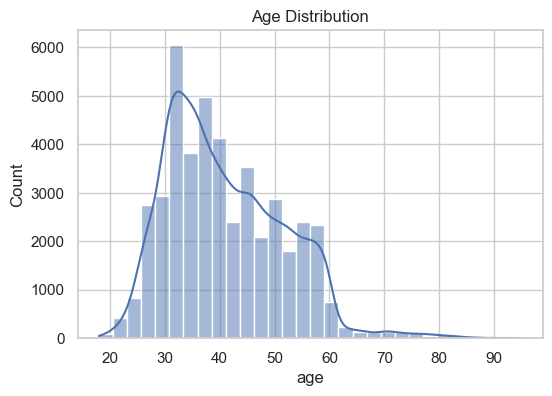

In [26]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


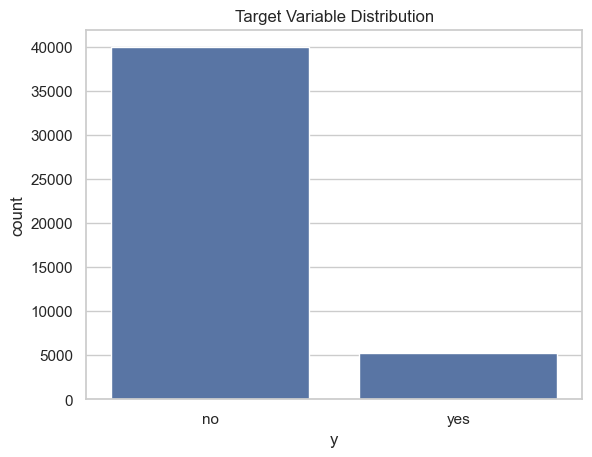

In [28]:
# Target distribution
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()


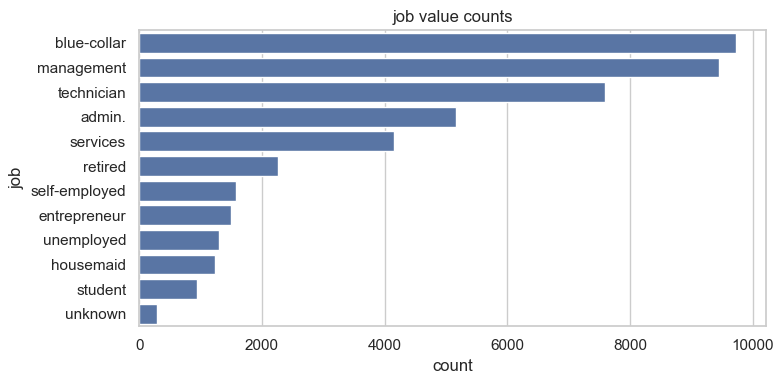

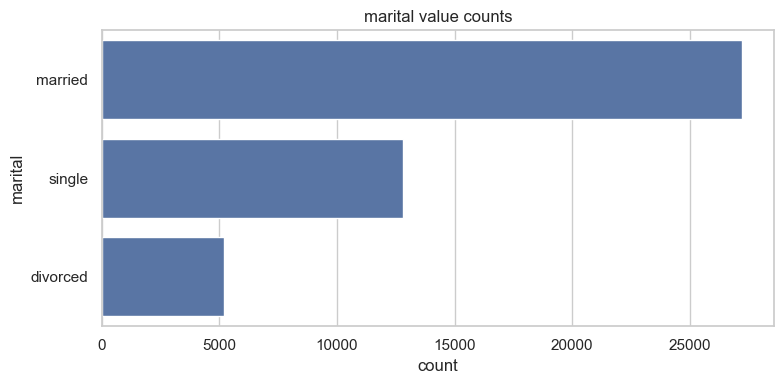

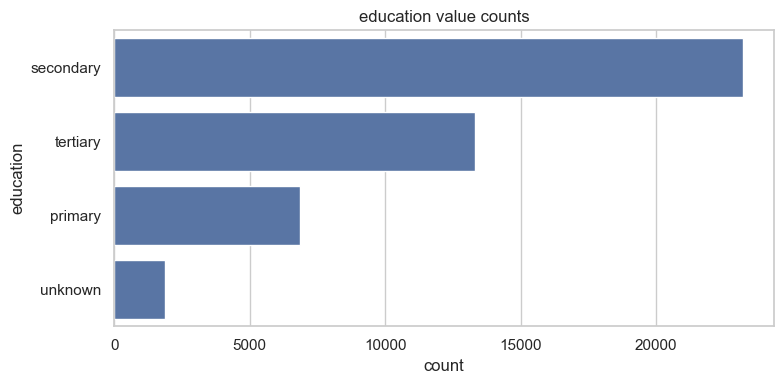

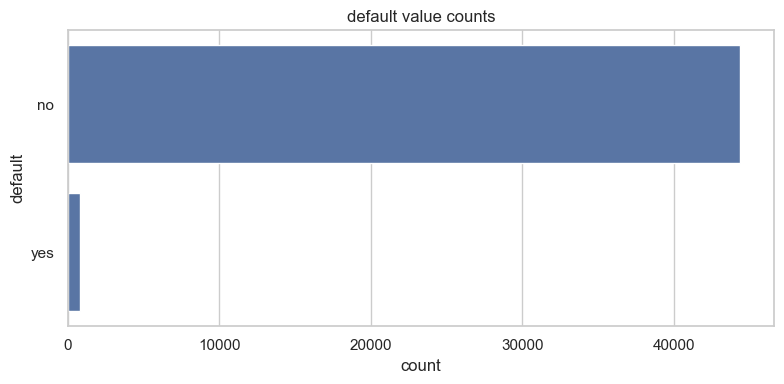

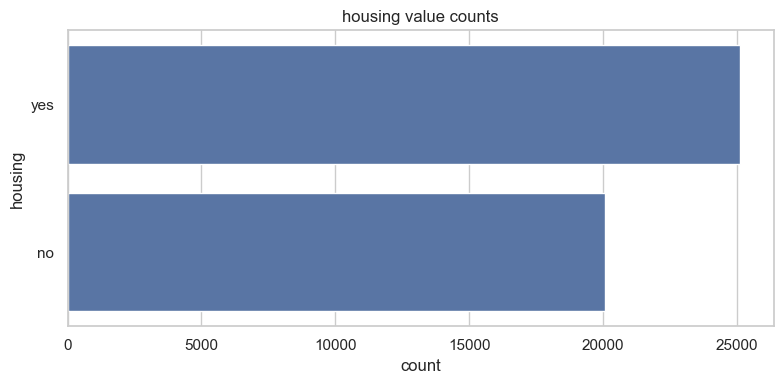

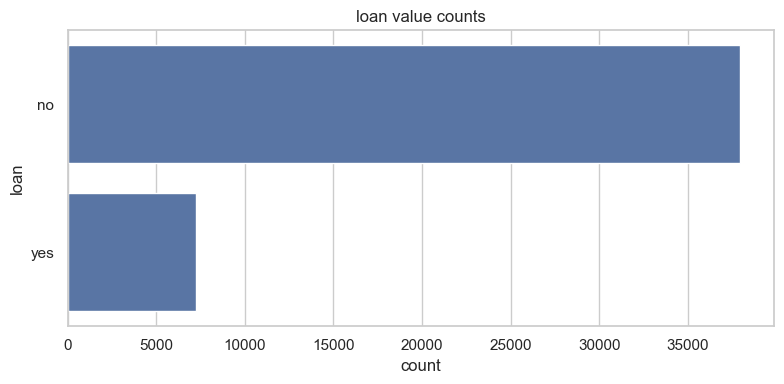

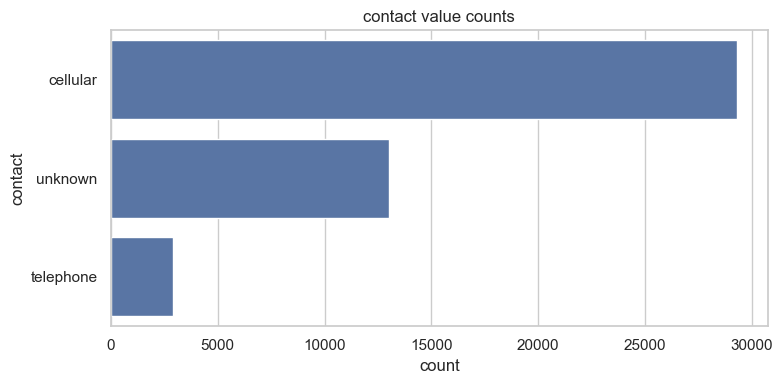

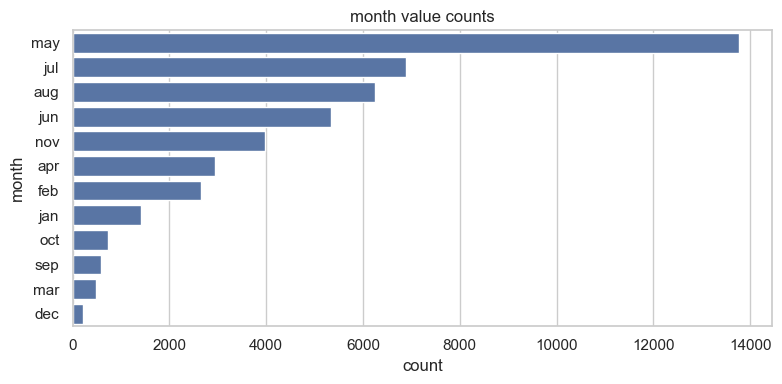

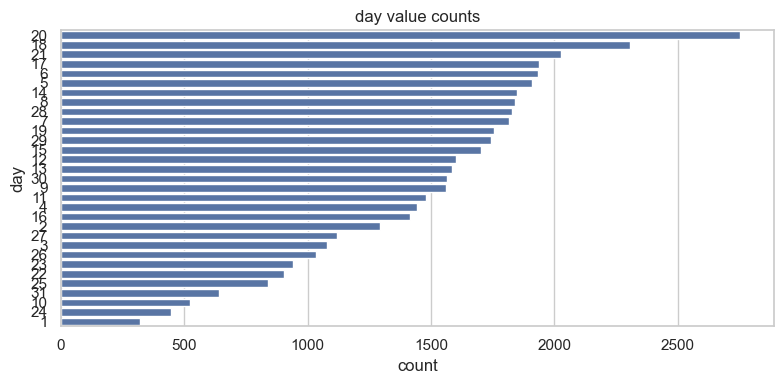

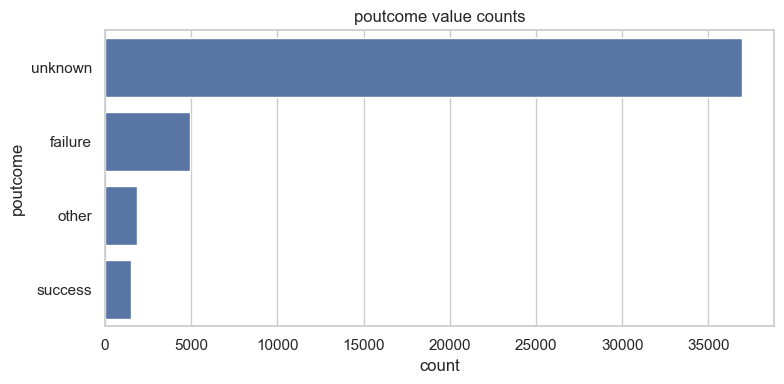

In [40]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day', 'poutcome']
for col in cat_cols:
    if col not in df.columns:
        print(f"Skipping missing column: {col}")
        continue
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col} value counts")
    plt.tight_layout()
    plt.show()


### Bivariate Analysis
- Relationship between features and `y`


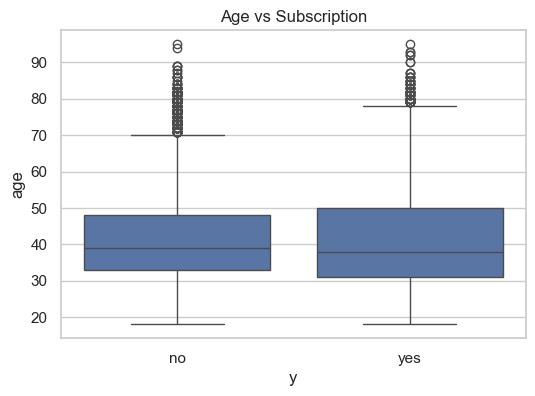

In [43]:
# Age vs y
plt.figure(figsize=(6,4))
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()


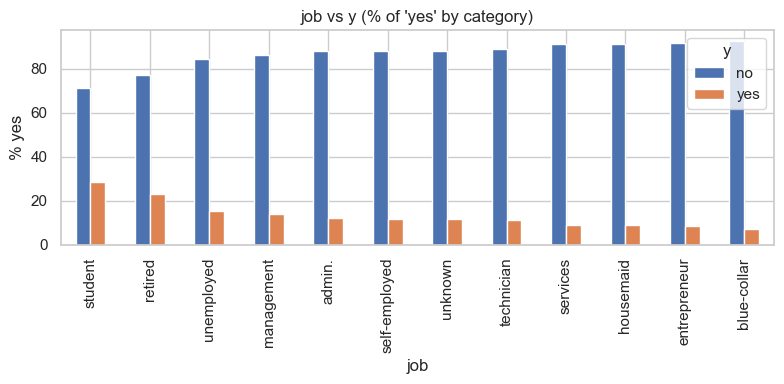

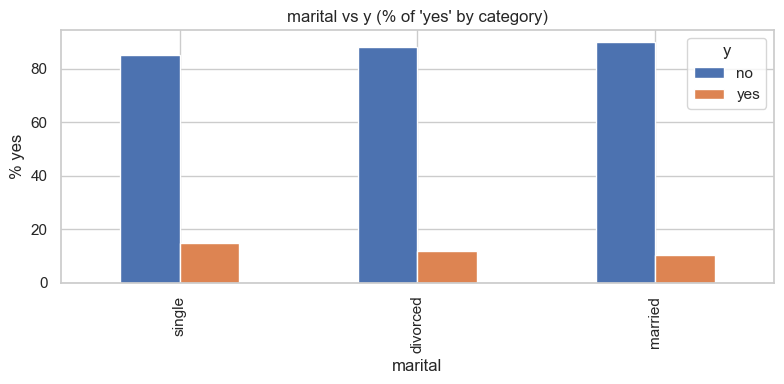

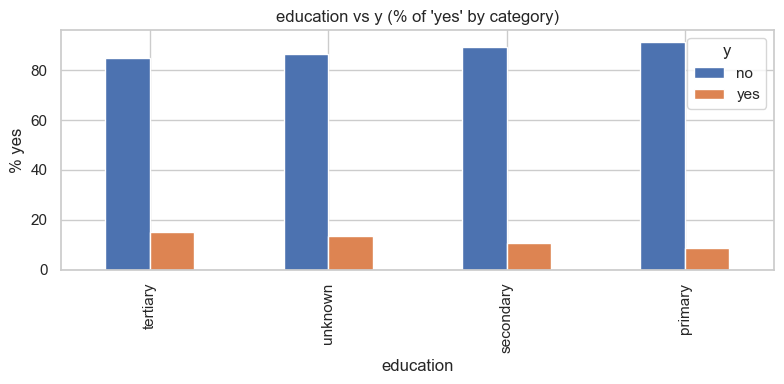

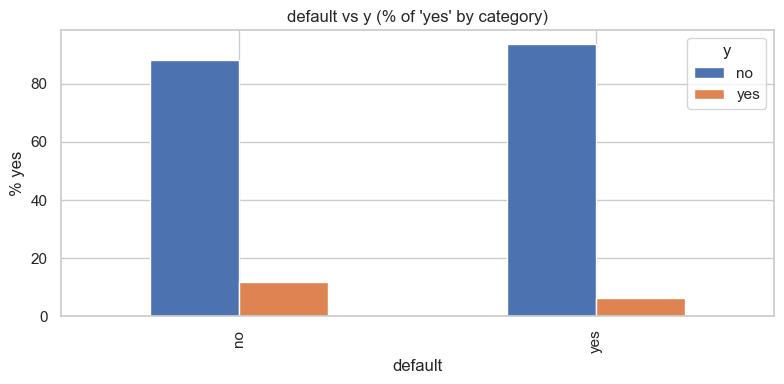

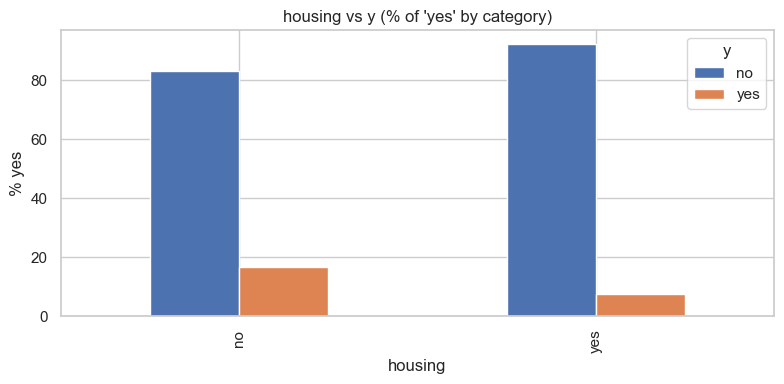

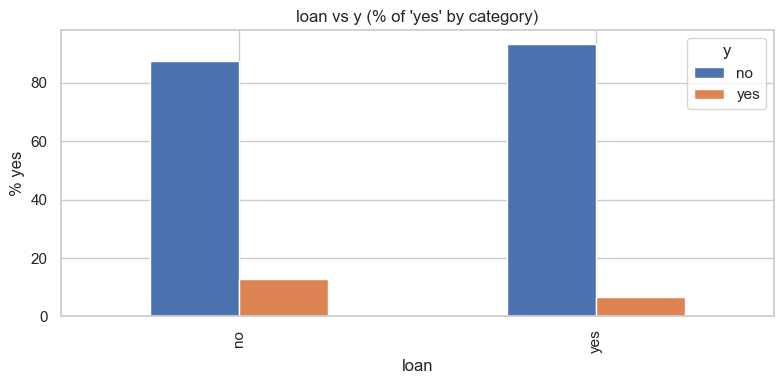

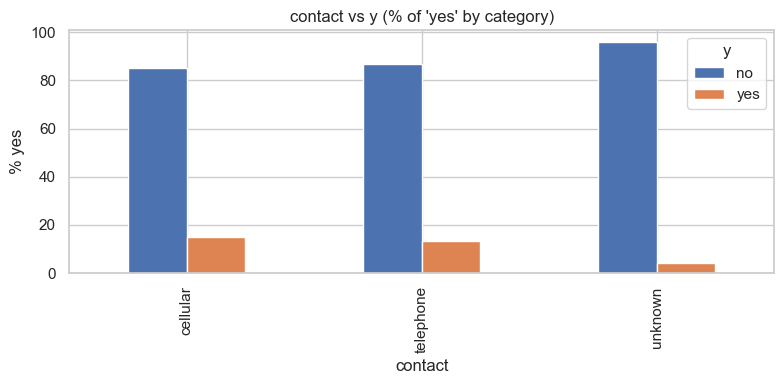

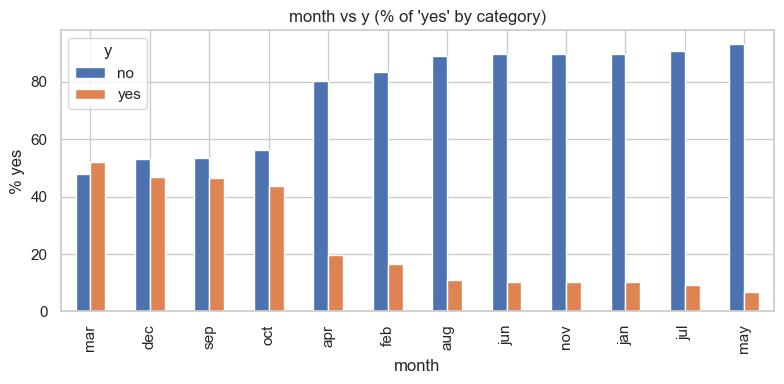

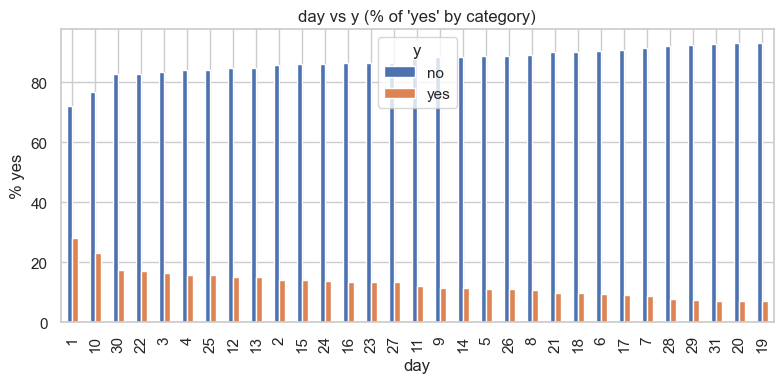

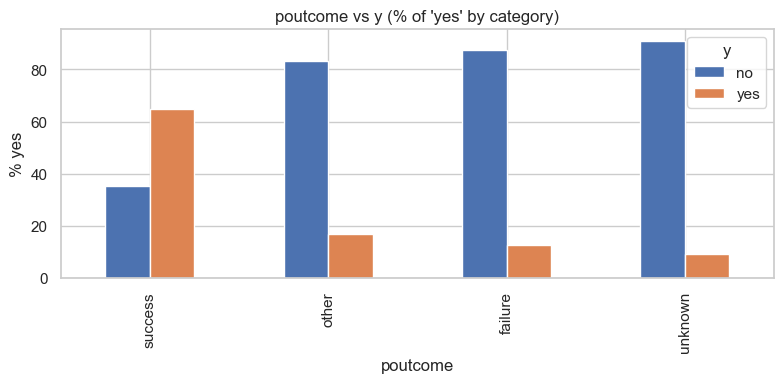

In [45]:
# Categorical vs target (normalized)
for col in cat_cols:
    cross_tab = (pd.crosstab(df[col], df['y'], normalize='index') * 100)
    cross_tab.sort_values('yes', ascending=False).plot(kind='bar', figsize=(8,4))
    plt.title(f"{col} vs y (% of 'yes' by category)")
    plt.ylabel("% yes")
    plt.tight_layout()
    plt.show()


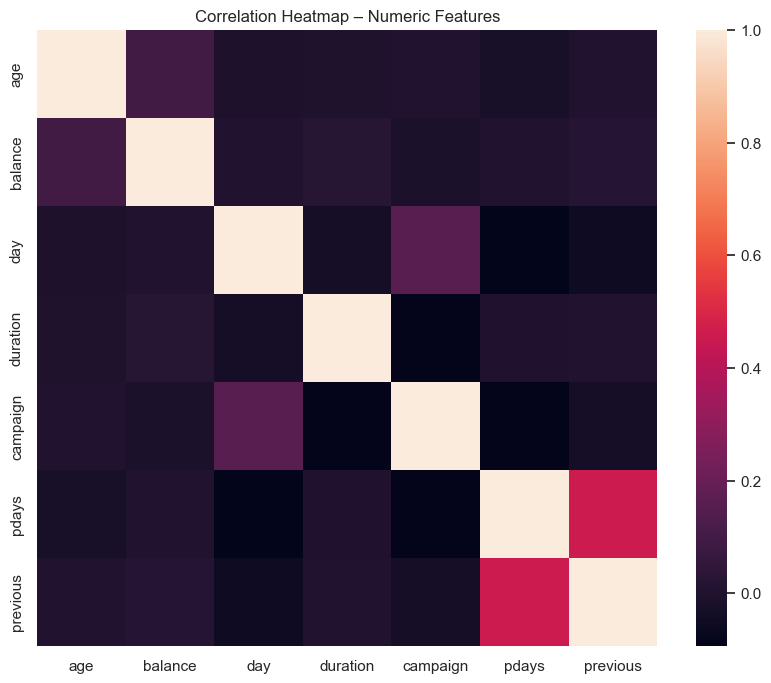

In [47]:
# Correlation between numeric variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=False)
plt.title("Correlation Heatmap – Numeric Features")
plt.show()


## Data Cleaning & Feature Engineering

Key points:
- Many categorical columns have `"unknown"`: treat as separate category or combine with most frequent.
- `pdays` uses 999 to mean “not previously contacted”.
- `duration` is data leakage (not known before the call ends) -> drop for realistic model.


In [50]:
df_clean = df.copy()

# Create a flag for previously contacted and treat 999 as -1 or separate value
df_clean['pdays_was_contacted'] = (df_clean['pdays'] != 999).astype(int)
# Optionally keep original pdays but replace 999 with -1
df_clean['pdays'] = df_clean['pdays'].replace(999, -1)

# Drop 'duration' to avoid leakage in the production model
df_clean = df_clean.drop(columns=['duration'])

df_clean.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,pdays_was_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no,1


In [52]:
# Encode target: 'yes' -> 1, 'no' -> 0
df_clean['y'] = df_clean['y'].map({'no': 0, 'yes': 1})


## Train–Test Split & Preprocessing

- Identify numeric and categorical columns
- Use `ColumnTransformer` with:
  - `StandardScaler` for numeric
  - `OneHotEncoder` for categorical
- Split into train and test sets


In [57]:
X = df_clean.drop('y', axis=1)
y = df_clean['y']

categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = [col for col in X.columns if col not in categorical_features]

categorical_features, numeric_features


(['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'poutcome'],
 ['age',
  'balance',
  'day',
  'campaign',
  'pdays',
  'previous',
  'pdays_was_contacted'])

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [61]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


# Model Building – Multiple Models & Comparison

## We’ll try three models (easy but strong):

### 1.Logistic Regression

### 2.Random Forest

### 3.Gradient Boosting (as a boosting baseline; use XGBoost if you like)

In [65]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
    # Optionally add XGBoost if installed
    # "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

results = []
best_pipelines = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    # Fit
    pipe.fit(X_train, y_train)
    best_pipelines[name] = pipe

    # Predict
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.66      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.87      9043


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.63      0.24      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.61      0.65      9043
weighted avg       0.87      0.89      0.87      9043


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.66      0.20      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59    

In [67]:
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Gradient Boosting,0.894283,0.659375,0.199433,0.306241,0.802262
1,Random Forest,0.894615,0.628993,0.241966,0.349488,0.789610
0,Logistic Regression,0.893288,0.663158,0.178639,0.281459,0.771749


### ROC Curves for Top 2 Models

<Figure size 600x500 with 0 Axes>

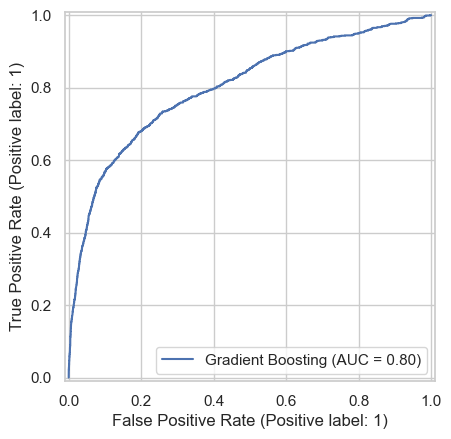

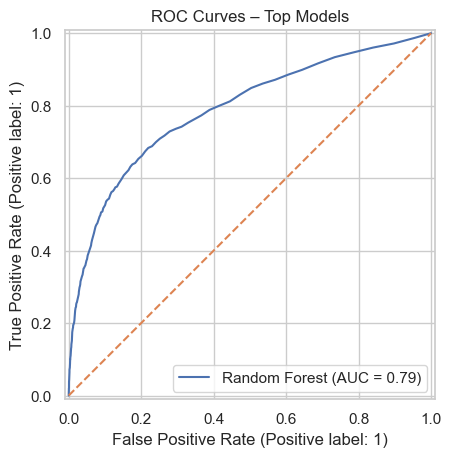

In [70]:
top2 = results_df.head(2)["Model"].tolist()

plt.figure(figsize=(6,5))
for name in top2:
    pipe = best_pipelines[name]
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name)
plt.title("ROC Curves – Top Models")
plt.plot([0,1],[0,1],'--')
plt.show()


# Confusion Matrix for Best Model

In [73]:
best_model_name = results_df.iloc[0]["Model"]
best_model = best_pipelines[best_model_name]
best_model_name


'Gradient Boosting'

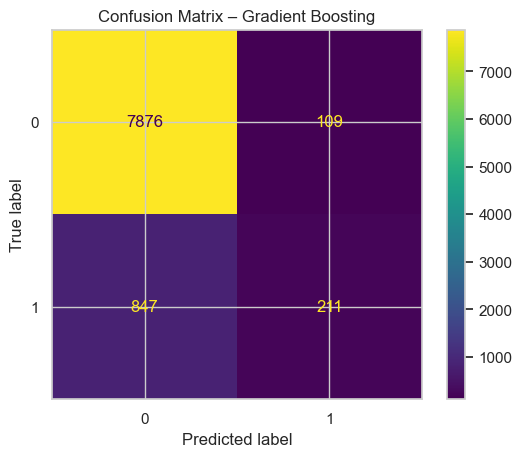

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()


# Model Interpretation (Feature Importance)

## For tree models you can show feature importance.

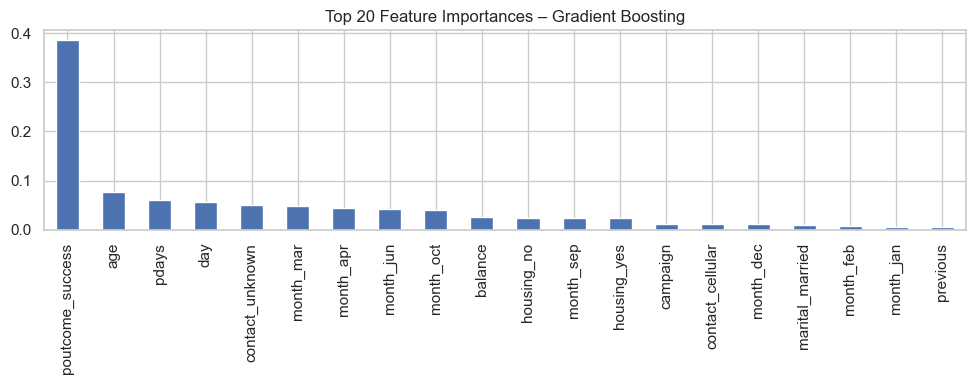

In [78]:
# Get feature names after one-hot encoding
ohe = best_model.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_features)
all_features = np.concatenate([numeric_features, ohe_features])

if hasattr(best_model.named_steps['model'], "feature_importances_"):
    importances = best_model.named_steps['model'].feature_importances_
    feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)
    feat_imp.head(20).plot(kind='bar', figsize=(10,4))
    plt.title(f"Top 20 Feature Importances – {best_model_name}")
    plt.tight_layout()
    plt.show()


# Model Comparison Report

## Model Comparison Report

| Model              | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|--------------------|----------|-----------|--------|----------|---------|
| (fill from results_df) |          |           |        |          |         |

- **Chosen metric**: ROC-AUC and F1-score are more important than accuracy because the classes are imbalanced (only a smaller proportion of customers say "yes").
- **Best model**: `<your best model from results_df>` – it gives the highest ROC-AUC and a good balance between precision and recall.
- **Reason for choosing**:
  - Handles non-linear relationships and complex interactions between features.
  - Works well with a mix of numeric and categorical variables after encoding.
  - Performance is stable under cross-validation (you can also add a `cross_val_score` section).


### If you want cross-validation for the best model:

In [84]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='roc_auc')
cv_scores.mean(), cv_scores.std()


(0.2533667084760175, 0.20446071705546293)

# Challenges Faced & Techniques Used

## Challenges Faced and Techniques Used

1. **Categorical variables (string columns)**
   - **Challenge**: Models like Logistic Regression and Random Forest cannot directly handle text labels such as `job = "technician"`, `marital = "single"`, etc.
   - **Technique**: Used `OneHotEncoder` inside a `ColumnTransformer` to convert categorical columns into numeric dummy variables. This solved errors like *"could not convert string to float: 'technician'"*.

2. **Class imbalance in target `y`**
   - **Challenge**: Majority of records are `y = 0 ("no")`, so high accuracy is possible even with a poor model.
   - **Technique**: 
     - Reported metrics like **precision, recall, F1-score, ROC-AUC** instead of only accuracy.
     - Optionally, you can try `class_weight="balanced"` in Logistic Regression or Random Forest to handle imbalance.

3. **Data leakage from `duration`**
   - **Challenge**: `duration` is only known after the call is completed and is highly predictive of the outcome. Using it in the model would lead to unrealistically high performance.
   - **Technique**: Dropped the `duration` column for the production model and used it only for exploratory / benchmark experiments (if at all).

4. **Special value 999 in `pdays`**
   - **Challenge**: `pdays = 999` means "not previously contacted" and should not be treated as normal numeric distance.
   - **Technique**: Created a flag `pdays_was_contacted` and replaced 999 with -1 in `pdays`, so the model can distinguish never-contacted customers.

5. **Different scales of numeric features**
   - **Challenge**: Features like `age`, `euribor3m`, `nr.employed` and `campaign` are on very different scales, which affects models such as Logistic Regression.
   - **Technique**: Applied `StandardScaler` to numeric columns inside the preprocessing pipeline.

6. **Multiple models & reproducibility**
   - **Challenge**: Need a clean way to try several models without repeating preprocessing code.
   - **Technique**: Used `Pipeline` and a Python dictionary of models. This allowed easy model swapping and consistent preprocessing.


# Business Suggestions for Bank Marketing Team

## Suggestions for the Bank Marketing Team

Based on the analysis and the best predictive model:

1. **Target high-potential customer segments**
   - Focus on age groups and job types that show a higher subscription rate (from the EDA tables).
   - Example: If `students`, `retired`, or `management` jobs show higher "yes" percentages, prioritize them in campaigns.

2. **Use previous campaign information**
   - Customers with `poutcome = "success"` or those previously contacted (low `pdays`) typically have a higher conversion probability.
   - Maintain and actively use historical campaign data to re-engage warm leads.

3. **Optimize contact strategy**
   - Use the model’s predictions to rank customers by probability of subscription and call high-score customers first.
   - Analyze which **month/day_of_week** shows higher success (from EDA) and schedule calls accordingly.

4. **Control contact frequency**
   - Very high values of `campaign` (too many contacts in the current campaign) may correlate with lower success, indicating customer fatigue.
   - Set an upper limit on number of calls per customer and stop after several failures.

5. **Product & communication personalization**
   - Use `housing`, `loan`, and `default` status to tailor the marketing script (e.g., customers without existing loans might be more open to term deposits).
   - Train agents with insights from feature importance (e.g., emphasize certain benefits for segments where those features matter more).

6. **Monitor macro-economic context**
   - Variables like `emp.var.rate`, `euribor3m`, and `cons.conf.idx` affect overall willingness to invest.
   - In periods of favorable economic indicators, consider increasing campaign intensity; reduce or adjust strategy in less favorable times.

7. **Continuous model monitoring**
   - Regularly retrain the model with new data to capture changes in customer behavior.
   - Track key metrics (ROC-AUC, recall, conversion rate) over time to ensure model remains reliable.


# Final Cell – Summary

## Conclusion

- Performed complete EDA to understand customer and campaign behavior.
- Built multiple ML models (Logistic Regression, Random Forest, Gradient Boosting) using a clean preprocessing pipeline.
- Selected **<best model name>** as the production candidate based on ROC-AUC and F1-score.
- Identified key drivers of term deposit subscription and proposed actionable strategies for the marketing team.
